<a href="https://colab.research.google.com/github/vappanna/BerAIML/blob/main/ProjectedUsage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- STEP 1: UPLOAD DATA ---
Please upload: 1. Install Base, 2. Usage History, 3. Sales Projections


Saving processed_usage.csv to processed_usage (2).csv
Saving Machine_Sales_Projection_2027.csv to Machine_Sales_Projection_2027 (5).csv
Saving processed_install_base.csv to processed_install_base (8).csv
✅ Files loaded successfully.

--- STEP 2: STANDARDIZING DATES ---
--- STEP 3: CALCULATING FLEET MATURITY CURVES ---


/tmp/ipykernel_11931/1796389034.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_proj['Period'] = pd.to_datetime(df_proj['Quarter']).dt.to_period('Q')


📈 Statistical Model Trained. R-Squared: 0.1061
--- STEP 4: GENERATING 2027 USAGE FORECAST ---

--- ✅ MISSION COMPLETE ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

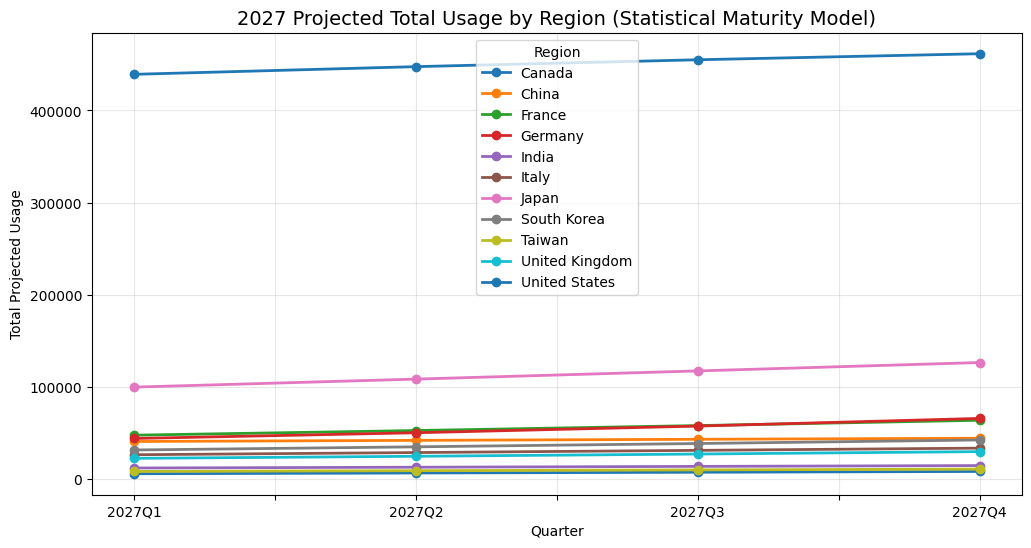

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from google.colab import files
import io

def run_complete_supply_chain_maturity_model():
    print("--- STEP 1: UPLOAD DATA ---")
    print("Please upload: 1. Install Base, 2. Usage History, 3. Sales Projections")
    uploaded = files.upload()

    # 1.1 IDENTIFY FILES
    try:
        ib_key = [k for k in uploaded.keys() if 'install' in k.lower()][0]
        usage_key = [k for k in uploaded.keys() if 'usage' in k.lower() or 'sheet1' in k.lower()][0]
        proj_key = [k for k in uploaded.keys() if 'projection' in k.lower()][0]

        df_ib = pd.read_csv(io.BytesIO(uploaded[ib_key]))
        df_usage = pd.read_csv(io.BytesIO(uploaded[usage_key]))
        df_proj = pd.read_csv(io.BytesIO(uploaded[proj_key]))
        print("✅ Files loaded successfully.")
    except Exception as e:
        print(f"❌ Error finding files: {e}. Check filenames for 'install', 'usage', and 'projection'.")
        return

    # --- STEP 2: DATE STANDARDIZATION (YYYYQx) ---
    print("\n--- STEP 2: STANDARDIZING DATES ---")

    # Standardize Install Base Dates
    df_ib['InstallDate'] = pd.to_datetime(df_ib['InstallDate'], errors='coerce')
    df_ib = df_ib.dropna(subset=['InstallDate', 'Machine'])
    df_ib['Install_Period'] = df_ib['InstallDate'].dt.to_period('Q')
    df_ib['Install_Quarter_Str'] = df_ib['Install_Period'].astype(str)

    # Standardize Sales Projection Dates
    df_proj['Period'] = pd.to_datetime(df_proj['Quarter']).dt.to_period('Q')

    # --- STEP 3: REGION MAPPING (Bridging History & Future) ---
    # Mapping the specific region names found in your files to a common key
    region_map = {
        'Asia : China': 'China', 'Asia : India': 'India', 'Asia : Japan': 'Japan',
        'Asia : Korea': 'South Korea', 'Asia : Taiwan': 'Taiwan', 'EU : France': 'France',
        'EU : Italy': 'Italy', 'EU : DACH': 'Germany', 'EU : UK & Ireland': 'United Kingdom',
        'US : West': 'United States', 'US : South Central': 'United States',
        'US : Southeast': 'United States', 'US : North Central': 'United States',
        'US : Northeast': 'United States', 'US : Pacific Mountain': 'United States',
        'US : Mid-Atlantic': 'United States', 'US : Mountain': 'United States',
        'US : Ohio Valley': 'United States', 'Canada : East': 'Canada', 'Canada : West': 'Canada'
    }

    df_usage['Common_Region'] = df_usage['REGION'].map(region_map).fillna('Other')

    # Direct Country-to-Common mapping for IB and Proj
    country_to_common = {
        'Germany': 'Germany', 'Austria': 'Germany', 'Switzerland': 'Germany',
        'China': 'China', 'United States': 'United States', 'Japan': 'Japan',
        'India': 'India', 'South Korea': 'South Korea', 'Taiwan': 'Taiwan',
        'France': 'France', 'Italy': 'Italy', 'United Kingdom': 'United Kingdom',
        'Ireland': 'United Kingdom', 'Canada': 'Canada'
    }
    df_ib['Common_Region'] = df_ib['Region'].map(country_to_common).fillna('Other')
    df_proj['Common_Region'] = df_proj['Region'].map(country_to_common).fillna('Other')

    # --- STEP 4: FEATURE ENGINEERING (Age & Maturity) ---
    print("--- STEP 3: CALCULATING FLEET MATURITY CURVES ---")
    history_rows = []
    usage_quarters = sorted(df_usage['QUARTER'].unique())

    for q_str in usage_quarters:
        target_q = pd.Period(q_str, freq='Q')
        active_fleet = df_ib[df_ib['Install_Period'] <= target_q]

        for (region, machine), group in active_fleet.groupby(['Common_Region', 'Machine']):
            if region == 'Other': continue

            ages = (target_q - group['Install_Period']).apply(lambda x: x.n)
            mean_age = ages.mean()
            fleet_size = len(group)

            usage_val = df_usage[(df_usage['Common_Region'] == region) &
                                 (df_usage['Machine'] == machine) &
                                 (df_usage['QUARTER'] == q_str)]['Usage'].sum()

            if fleet_size > 0:
                history_rows.append({
                    'Mean_Age': mean_age, 'Region': region, 'Machine': machine,
                    'Usage_per_Machine': usage_val / fleet_size
                })

    df_train = pd.DataFrame(history_rows)

    # Training the Model (Age + Age^2 + Regional Fixed Effects)
    df_train['Age2'] = df_train['Mean_Age'] ** 2
    reg_dummies = pd.get_dummies(df_train['Region'], prefix='Reg')
    X = pd.concat([df_train[['Mean_Age', 'Age2']], reg_dummies], axis=1)
    y = df_train['Usage_per_Machine']

    model = LinearRegression().fit(X, y)
    print(f"📈 Statistical Model Trained. R-Squared: {model.score(X, y):.4f}")

    # --- STEP 5: 2027 PROJECTION ENGINE ---
    print("--- STEP 4: GENERATING 2027 USAGE FORECAST ---")
    projection_quarters = ['2027Q1', '2027Q2', '2027Q3', '2027Q4']
    future_results = []

    for target_q_str in projection_quarters:
        target_q = pd.Period(target_q_str, freq='Q')

        # Merge existing fleet with projected new installs
        active_ib = df_ib[df_ib['Install_Period'] < target_q]
        active_proj = df_proj[df_proj['Period'] < target_q]

        for region in df_train['Region'].unique():
            for machine in df_train['Machine'].unique():
                # IB Contribution
                sub_ib = active_ib[(active_ib['Common_Region'] == region) & (active_ib['Machine'] == machine)]
                ib_count = len(sub_ib)
                ib_age = (target_q - sub_ib['Install_Period']).apply(lambda x: x.n).sum() if ib_count > 0 else 0

                # Projection Contribution
                sub_proj = active_proj[(active_proj['Common_Region'] == region) & (active_proj['Machine'] == machine)]
                proj_count = sub_proj['Projected_Install_Count'].sum()
                proj_age = (sub_proj['Projected_Install_Count'] * (target_q - sub_proj['Period']).apply(lambda x: x.n)).sum() if proj_count > 0 else 0

                total_fleet = ib_count + proj_count
                if total_fleet > 0:
                    mean_age = (ib_age + proj_age) / total_fleet
                    reg_vec = [1 if f"Reg_{region}" == col else 0 for col in reg_dummies.columns]
                    X_pred = pd.DataFrame([[mean_age, mean_age**2] + reg_vec], columns=X.columns)
                    intensity = max(0, model.predict(X_pred)[0])

                    future_results.append({
                        'Quarter': target_q_str, 'Region': region, 'Machine': machine,
                        'Fleet_Size': total_fleet, 'Mean_Age': round(mean_age, 2),
                        'Projected_Usage_Units': round(intensity * total_fleet, 0)
                    })

    df_final = pd.DataFrame(future_results)

    # --- STEP 6: VISUALIZATION & EXPORT ---
    plt.figure(figsize=(12, 6))
    summary = df_final.groupby(['Quarter', 'Region'])['Projected_Usage_Units'].sum().unstack()
    summary.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())
    plt.title('2027 Projected Total Usage by Region (Statistical Maturity Model)', fontsize=14)
    plt.ylabel('Total Projected Usage')
    plt.grid(True, alpha=0.3)
    plt.savefig("Projected_2027_Usage.png")

    df_final.to_csv("FINAL_2027_STATISTICAL_USAGE_PROJECTION.csv", index=False)
    print("\n--- ✅ MISSION COMPLETE ---")
    files.download("FINAL_2027_STATISTICAL_USAGE_PROJECTION.csv")
    files.download("Projected_2027_Usage.png")

# Execute the workflow
run_complete_supply_chain_maturity_model()